In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,f1_score,recall_score
from sklearn.ensemble import StackingClassifier,AdaBoostClassifier
from sklearn.svm import SVC

from scipy.stats import pearsonr


import warnings
warnings.filterwarnings('ignore')


Loadind dataset

In [163]:
df=pd.read_csv('college_student_placement_dataset.csv')
df.head(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
5,CLG0015,96,5.26,5.32,7,No,5,8,0,No
6,CLG0071,123,6.68,6.58,5,No,7,8,2,Yes
7,CLG0096,111,8.77,8.76,7,No,3,1,2,Yes
8,CLG0097,92,6.47,6.33,9,No,7,8,5,No
9,CLG0057,108,8.82,8.60,4,No,5,9,1,No


EDA

In [164]:
df.shape

(10000, 10)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [166]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


Data cleaning

In [167]:
df.isna().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

Data visualization

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103],
 [Text(0, 0, '41'),
  Text(1, 0, '42'),
  Text(2, 0, '44'),
  Text(3, 0, '45'),
  Text(4, 0, '51'),
  Text(5, 0, '52'),
  Text(6, 0, '54'),
  Text(7, 0, '55'),
  Text(8, 0, '56'),
  Text(9, 0, '57'),
  Text(10, 0, '58'),
  Text(11, 0, '59'),
  Text(12, 0, '60'),
  Text(13, 0, '61'),
  Text(14, 0, '62'),
  Text(15, 0, '63'),
  Text(16, 0, '64'),
  Text(17, 0, '65'),
  Text(18, 0,

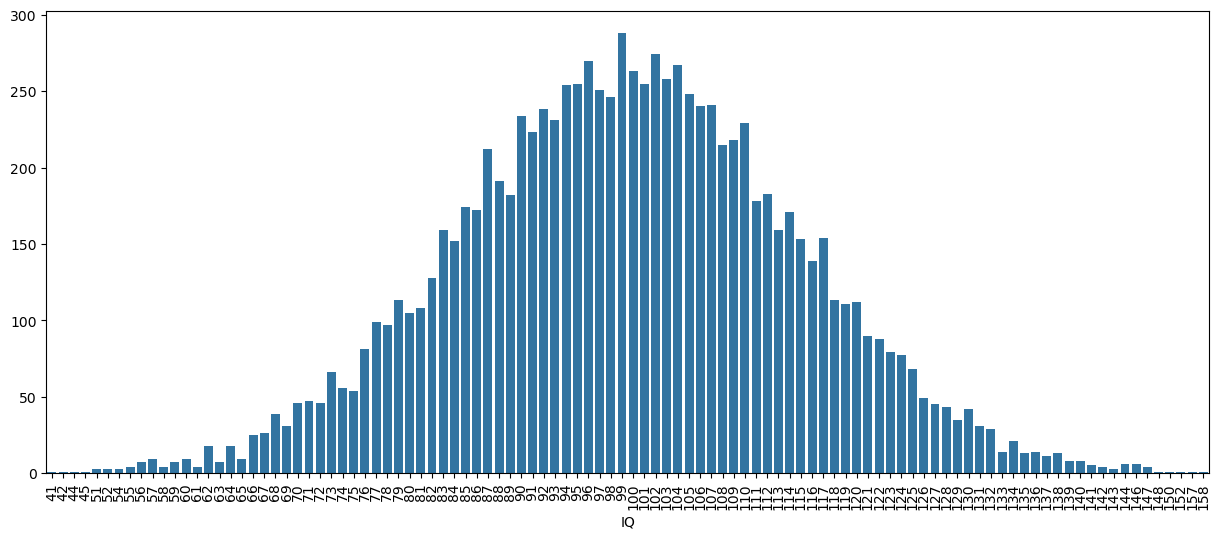

In [168]:
IQcount=df['IQ'].value_counts()
plt.figure(figsize=(15,6))
sns.barplot(x=IQcount.index,y=IQcount.values)
plt.xticks(rotation=90)
# plt.show()

In [169]:
df['Placement'].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

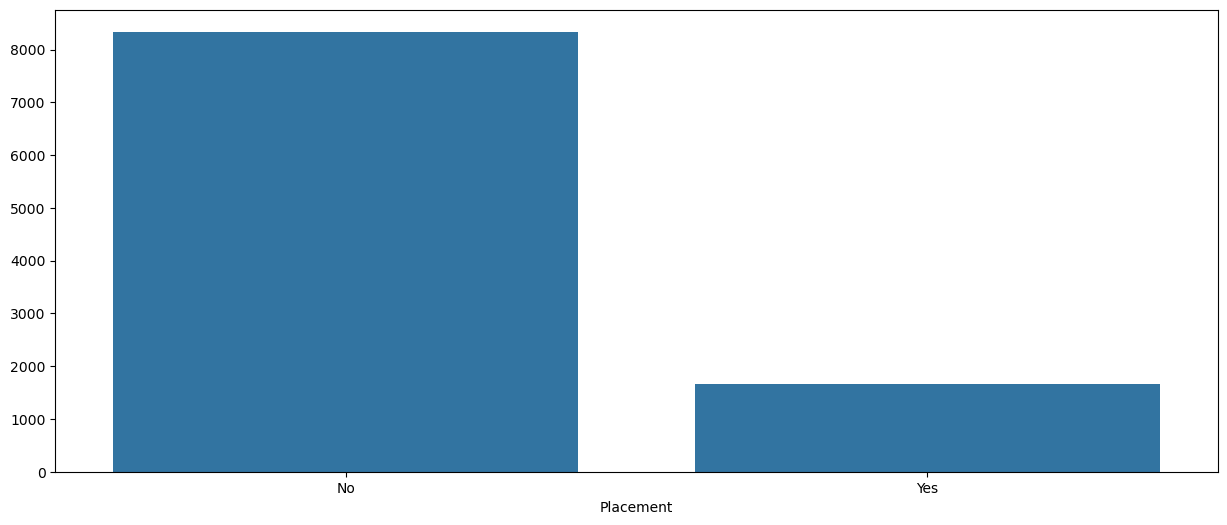

In [170]:
placementCount=df['Placement'].value_counts()
plt.figure(figsize=(15,6))
sns.barplot(x=placementCount.index,y=placementCount.values)
plt.show()

<Axes: xlabel='Communication_Skills'>

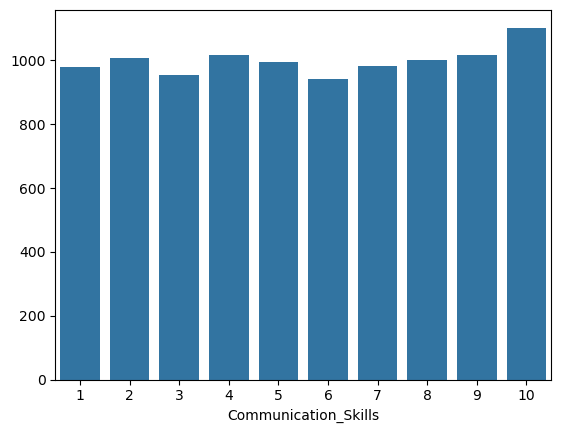

In [171]:
CommunicationCount=df['Communication_Skills'].value_counts()
sns.barplot(x=CommunicationCount.index,y=CommunicationCount.values)

In [172]:
def encoding(dataset,cols):
    for col in cols:
        encoder=LabelEncoder()
        dataset[col]=encoder.fit_transform(dataset[col])
    return dataset

qualitative_cols=['Placement','Internship_Experience']

scaled_df=df.copy()
encoding(scaled_df,qualitative_cols)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,0,1,8,0,1
9996,CLG0098,70,9.25,9.34,7,0,0,7,2,0
9997,CLG0066,89,6.08,6.25,3,1,3,9,5,0
9998,CLG0045,107,8.77,8.92,3,0,7,5,1,0


In [173]:
scaled_df.corr(numeric_only=True)['Placement'].sort_values(ascending=False)

Placement                 1.000000
Communication_Skills      0.323155
CGPA                      0.321607
Prev_Sem_Result           0.317896
IQ                        0.285914
Projects_Completed        0.217499
Extra_Curricular_Score   -0.004740
Internship_Experience    -0.005841
Academic_Performance     -0.014920
Name: Placement, dtype: float64

<Axes: >

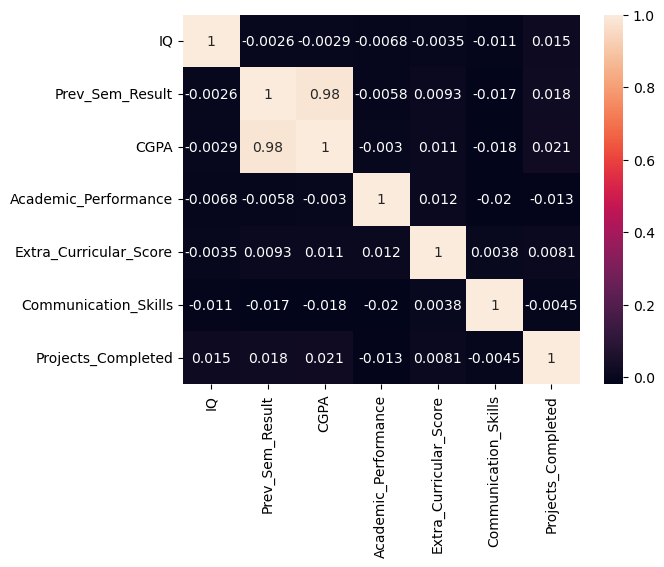

In [174]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Standart scaling

In [175]:
def scaling(dataset,cols):
    scaler=StandardScaler()
    dataset[cols]=scaler.fit_transform(dataset[cols])
    return dataset

numerical_cols = [
    'IQ',
    'Prev_Sem_Result',
    'CGPA',
    'Academic_Performance',
    'Extra_Curricular_Score',
    'Communication_Skills',
    'Projects_Completed',
    'Internship_Experience'
]

scaling(scaled_df,numerical_cols)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,0.500135,-0.639521,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,CLG0061,-0.164214,-1.392572,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,CLG0036,0.633004,-1.503111,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,CLG0055,1.496657,-1.427115,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000,0
4,CLG0004,-0.230648,0.258612,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206,0
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,1.297352,0.604048,0.515365,-0.538190,-0.810387,-1.256636,0.840550,-1.464794,1
9996,CLG0098,-1.957954,1.184380,1.229618,0.505893,-0.810387,-1.573097,0.495808,-0.299206,0
9997,CLG0066,-0.695692,-1.005683,-0.872327,-0.886218,1.233979,-0.623713,1.185292,1.449175,0
9998,CLG0045,0.500135,0.852762,0.943917,-0.886218,-0.810387,0.642131,-0.193676,-0.882000,0


In [176]:
selected_features=['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed']

correlations={
    feature: pearsonr(scaled_df[feature],scaled_df['Placement'])[0]
    for feature in selected_features
}

correlationsDF= pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson Correlation'])
correlationsDF.sort_values(by="Pearson Correlation",ascending=False)

,Feature,Pearson Correlation
6,Communication_Skills,0.323155
2,CGPA,0.321607
1,Prev_Sem_Result,0.317896
0,IQ,0.285914
7,Projects_Completed,0.217499
5,Extra_Curricular_Score,-0.004740
4,Internship_Experience,-0.005841
3,Academic_Performance,-0.014920


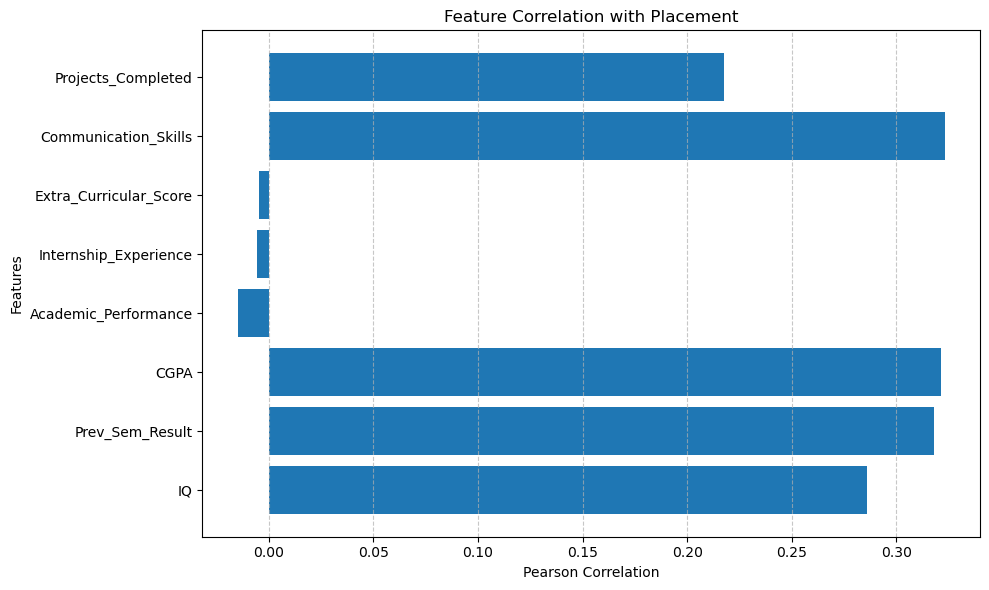

In [177]:


plt.figure(figsize=(10, 6))
plt.barh(
    correlationsDF["Feature"],
    correlationsDF["Pearson Correlation"]
)
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.title("Feature Correlation with Placement")
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [178]:
scaled_df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [179]:
final_df=scaled_df[['IQ', 'Prev_Sem_Result', 'CGPA','Academic_Performance','Internship_Experience',
       'Communication_Skills', 'Projects_Completed','Placement']]

final_df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.639521,-0.851919,0.853921,-0.810387,0.840550,0.866381,0
1,-0.164214,-1.392572,-1.470939,0.853921,-0.810387,0.840550,-1.464794,0
2,0.633004,-1.503111,-1.158028,1.201949,-0.810387,-1.572644,-0.882000,0
3,1.496657,-1.427115,-1.212447,0.157865,1.233979,0.151066,-0.882000,0
4,-0.230648,0.258612,0.107220,0.505893,-0.810387,1.530034,-0.299206,0


Spliting X and y

In [180]:
X=final_df.drop('Placement',axis=1)
y=final_df['Placement']



Train test split

In [181]:
XTrain,XTest,yTrain,yTest= train_test_split(X,y,test_size=0.2,random_state=42)

Model tunning

In [182]:
models={
    'LogisticRegression':LogisticRegression(C=1,solver='liblinear',max_iter=5000),
    'KNN': KNeighborsClassifier(metric='manhattan',n_neighbors=11,weights='distance'),
    'DecisionTree':DecisionTreeClassifier(criterion='gini',max_depth=None,min_samples_leaf=1,min_samples_split=2,random_state=42),
    'GaussianNB':GaussianNB(var_smoothing=1e-09),
    'adaBoost':AdaBoostClassifier(random_state=42,learning_rate=0.1,n_estimators=100),
    'SVM': SVC(C=100,gamma='scale',kernel='rbf')
    
}

models evalulation

In [183]:
results= []

for name,model in models.items():
    model.fit(XTrain,yTrain)
    y_pred= model.predict(XTest)

    results.append({
        'Model': name,
        'Accuracy':round(accuracy_score(yTest,y_pred)*100,2),
        'Recall':round(recall_score(yTest,y_pred)*100,2),
        'F1 Score':round(f1_score(yTest,y_pred)*100,2)
    })

results_df= pd.DataFrame(results)
results_df.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy,Recall,F1 Score
2,DecisionTree,100.00,100.00,100.00
4,adaBoost,100.00,100.00,100.00
5,SVM,98.65,94.79,95.81
1,KNN,97.15,85.58,90.73
3,GaussianNB,91.05,64.72,70.22
0,LogisticRegression,90.15,60.74,66.78


Stacking

In [184]:
base_models=[
    ('SVM',models['SVM']),
    ('Lr',models['LogisticRegression']),
    ('NB',models['GaussianNB'])
]

meta_model=models['KNN']

classifier=StackingClassifier(estimators=base_models,final_estimator=meta_model,cv=5)
classifier.fit(XTrain,yTrain)
y_pred=classifier.predict(XTest)

print(f"Accuracy: {accuracy_score(yTest,y_pred)*100:.2f}%")

Accuracy: 98.40%


In [185]:
X.columns

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

Inputs

In [186]:
IQ = float(input("Enter IQ: "))
Prev_Sem_Result = float(input("Enter Previous Semester Result: "))
CGPA = float(input("Enter CGPA: "))
Communication_Skills = float(input("Enter Communication Skills: "))
Projects_Completed = int(input("Enter Number of Projects Completed: "))
Internship_Experience=input("Any internship experience(yes/no) ?")
Academic_Performance= int(input("Enter your Academic Performance"))

user_input = pd.DataFrame({
    'IQ': [IQ],
    'Prev_Sem_Result': [Prev_Sem_Result],
    'CGPA': [CGPA],
    'Academic_Performance':Academic_Performance,
    'Internship_Experience':[1 if Internship_Experience.lower()=='yes' else 0],
    'Communication_Skills': [Communication_Skills],
    'Projects_Completed': [Projects_Completed],
})

scaled_userInput=user_input.copy()

numerical_cols = [
    'IQ',
    'Prev_Sem_Result',
    'CGPA',
    'Communication_Skills',
    'Projects_Completed',
    'Internship_Experience',
    'Academic_Performance'
]

scaling(scaled_userInput,numerical_cols)

result= classifier.predict(scaled_userInput)

if result==1:
    print("The student may be palced")
else:
    print("The student may not be palced")
    
user_df=pd.DataFrame(user_input)
print("Input details:\n")
print(user_df)

print(result)

The student may not be palced
Input details:

      IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0  112.0             6.49  8.99                     9                      1   

   Communication_Skills  Projects_Completed  
0                   8.0                   5  
[0]


This model is good but it's dataset is bad, there are less number of palced student

<Axes: xlabel='Placement'>

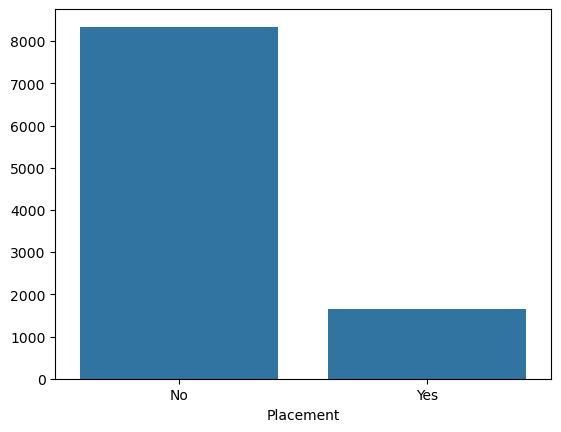

In [187]:
placementCount=df['Placement'].value_counts()
sns.barplot(x=placementCount.index,y=placementCount.values)
